In [1]:
from typing import Callable
import numpy as np
from matplotlib import pyplot as plt
import scipy
from scipy.special import eval_legendre

class Recurence:
    def __init__(self,l_max:int, c0:float):
        self.l_max = l_max
        self.c0 = c0

    def qm(self, l: np.ndarray, c0:float):
        mask = l>=2
        val = -2*c0*l/(2*l-1)
        val[mask] += -c0*l[mask]*(l[mask]-1)/(2*l[mask]-1)
        return val

    def q0(self, l: np.ndarray, c0: float):
        return -l*(l+1)

    def qp(self, l: np.ndarray, c0: float):
        return c0*(l+1)*(l+2)/(2*l+3) - 2*c0*(l+1)/(2*l+3)

    def qm_lambda(self, l: np.ndarray, c0: float):
        return l/(2*l-1)

    def qp_lambda(self, l: np.ndarray, c0: float):
        return (l+1)/(2*l+3)

    def generate_matrix(self): 
        l_max = self.l_max
        c0 = self.c0
        A = np.zeros((l_max,l_max))
        B = np.zeros((l_max,l_max))
        l = np.arange(1,l_max+1)
        l_matrix = l-1 # the corresponding matrix entry indices; recurrence starts at l=1
        Qm = self.qm(l,c0)
        Q0 = self.q0(l,c0)
        Qp = self.qp(l,c0)
        Qm_lambda = self.qm_lambda(l,c0)
        Qp_lambda = self.qp_lambda(l,c0)

        A[l_matrix,l_matrix] = Qm
        A[l_matrix[:-1],l_matrix[1:]] = Q0[:-1]
        A[l_matrix[:-2],l_matrix[2:]]= Qp[:-2]
        B[l_matrix, l_matrix] = Qm_lambda
        B[l_matrix[:-2], l_matrix[2:]] = Qp_lambda[:-2]

        return A, B

# always shift indices -1 for the matrices

In [2]:
rec = Recurence(l_max=10, c0=1.)
A, B = rec.generate_matrix()

np.set_printoptions(precision=3, suppress=True, linewidth=120)
print(A)
print(B)

[[ -2.     -2.      0.4     0.      0.      0.      0.      0.      0.      0.   ]
 [  0.     -2.     -6.      0.857   0.      0.      0.      0.      0.      0.   ]
 [  0.      0.     -2.4   -12.      1.333   0.      0.      0.      0.      0.   ]
 [  0.      0.      0.     -2.857 -20.      1.818   0.      0.      0.      0.   ]
 [  0.      0.      0.      0.     -3.333 -30.      2.308   0.      0.      0.   ]
 [  0.      0.      0.      0.      0.     -3.818 -42.      2.8     0.      0.   ]
 [  0.      0.      0.      0.      0.      0.     -4.308 -56.      3.294   0.   ]
 [  0.      0.      0.      0.      0.      0.      0.     -4.8   -72.      3.789]
 [  0.      0.      0.      0.      0.      0.      0.      0.     -5.294 -90.   ]
 [  0.      0.      0.      0.      0.      0.      0.      0.      0.     -5.789]]
[[1.    0.    0.4   0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.667 0.    0.429 0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.6   0.    0.444 0.    0.   

In [3]:
# Solving for eigenvalues and eigenvectors
l_max = 100
c0=1.

rec = Recurence(l_max=l_max, c0=c0)
A, B = rec.generate_matrix()
eig_vals, eig_vecs =scipy.linalg.eig(a=A,b=B)
# eig_vals, eig_vecs, eig_vecs[:,4] # 5th eigenvector

In [4]:
def eigenfunction(eig_vecs, mode):
    coeffs = eig_vecs[:,mode]
    def eigen_fun(x):
        val = 0
        for l, a_l in enumerate(coeffs):
            val += a_l*eval_legendre(l,x)
        return val
    return eigen_fun

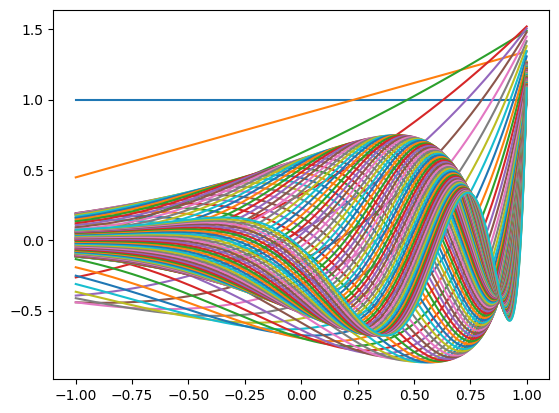

In [5]:
x = np.linspace(-1,1,400)
for n in range(l_max):
    f_n = eigenfunction(eig_vecs,n)
    plt.plot(x,f_n(x))
plt.show()

In [6]:
def plot_eigenfunction(eig_vecs, mode):
    """
    Plot the eigenfunction corresponding to eig_vecs[:, mode]

    Parameters
    ----------
    eig_vecs : ndarray
        Matrix of eigenvectors returned by scipy.linalg.eig.
        Columns are eigenvectors.
    mode : int
        Eigenvector index (e.g. 4 for the 5th eigenvector eig_vecs[:,4]).
    """

    x = np.linspace(-1,1,400)

    coeffs = eig_vecs[:, mode]

    # Build eigenfunction:
    # f(x) = sum_l a_l P_l(x)
    f = np.zeros_like(x, dtype=np.complex128)

    for l, a_l in enumerate(coeffs):
        f += a_l * eval_legendre(l, x)

    plt.figure(figsize=(6,4))
    
    if np.max(np.abs(np.imag(f))) > 1e-12:
        plt.plot(x, np.real(f), label="Re")
        plt.plot(x, np.imag(f), "--", label="Im")
    else:
        plt.plot(x, np.real(f))
    plt.xlabel(r"$x = \cos(\theta)$")
    plt.ylabel(r"$f(x)$")
    plt.title(f"Eigenfunction for mode {mode}")
    plt.grid(True)
    plt.show()

In [ ]:
# GPT's code for the other branch of solutions

from typing import Tuple
import numpy as np
import scipy.linalg


class PowerSeriesRecurrence:
    """
    Generalized eigenvalue problem for

    (1-x^2)R''
    - (c0(1-x^2)+2x)R'
    - lambda*x*R = 0

    with power series

        R(x) = sum_n a_n x^n

    recurrence:

    (n+2)(n+1)a_{n+2}
    - c0(n+1)a_{n+1}
    - n(n+1)a_n
    + c0(n-1)a_{n-1}
    = lambda * a_{n-1}
    """

    def __init__(self, n_max: int, c0: float):
        self.n_max = n_max
        self.c0 = c0

    # ---------- recurrence coefficients ----------

    def a_p2(self, n: np.ndarray):
        return (n + 2) * (n + 1)

    def a_p1(self, n: np.ndarray):
        return -self.c0 * (n + 1)

    def a_0(self, n: np.ndarray):
        return -n * (n + 1)

    def a_m1(self, n: np.ndarray):
        return self.c0 * (n - 1)

    def lambda_coeff(self, n: np.ndarray):
        return np.ones_like(n, dtype=float)

    # ---------- matrix construction ----------

    def generate_matrix(self) -> Tuple[np.ndarray, np.ndarray]:

        N = self.n_max + 1

        A = np.zeros((N, N), dtype=float)
        B = np.zeros((N, N), dtype=float)

        n = np.arange(N)

        Ap2 = self.a_p2(n)
        Ap1 = self.a_p1(n)
        A0  = self.a_0(n)
        Am1 = self.a_m1(n)

        # diagonal
        A[n, n] = A0

        # +1 diagonal
        mask = n + 1 < N
        A[n[mask], n[mask] + 1] = Ap1[mask]

        # +2 diagonal
        mask = n + 2 < N
        A[n[mask], n[mask] + 2] = Ap2[mask]

        # -1 diagonal
        mask = n >= 1
        A[n[mask], n[mask] - 1] = Am1[mask]

        # generalized eigenvalue matrix
        # lambda * a_{n-1}

        B[n[mask], n[mask] - 1] = 1.0

        return A, B

    # ---------- eigensolver ----------

    def solve(self):
        A, B = self.generate_matrix()
        eigvals, eigvecs = scipy.linalg.eig(A, B)
        return eigvals, eigvecs